In [1]:
import pandas as pd
import pycrosstalker
import numpy as np 
import networkx as nx
import igraph as ig
import leidenalg 
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.patches import Patch
from community_layout.layout_class import CommunityLayout
import nichesphere
import scanpy as sc


COMMUNITY LAYOUT: Datashader not found, edge bundling not available


In [2]:
import module_04_pyctkr_nw_stats as m04

In [3]:
CCI_tab = pd.read_csv("../res_data/revision/MF/Jak2_CCI_table.csv")

In [4]:
CCI_tab['to'].unique()

array(['Classical_monocytes_Mut', 'Neutrophils_Mut', 'SPP1_Macrophages',
       'Macrophages_Mut', 'Late_Neutro_Prog_Mut', 'HSPCs_Mut',
       'CD16_monocytes_Mut', 'HSPCs', 'pDCs', 'SPP1_Macrophages_Mut',
       'pDCs_Mut', 'Inflammatory_CD14_monocytes_Mut', 'GMPs_Mut',
       'cDC2_Mut'], dtype=object)

In [5]:
mut=pd.Series(CCI_tab['from'].unique()).str.contains('Mut')
mut=pd.Series(CCI_tab['from'].unique())[mut]
mut=list(mut)+['Adipo_CAR', 'OLCs', 'Arterial_EC', 'Osteoblasts', 'Sinusoidal_EC', 'SPP1_Macrophages', 'MK_prog']
mut

['pDCs_Mut',
 'HSPCs_Mut',
 'SPP1_Macrophages_Mut',
 'CD16_monocytes_Mut',
 'Macrophages_Mut',
 'Classical_monocytes_Mut',
 'GMPs_Mut',
 'Inflammatory_CD14_monocytes_Mut',
 'cDC2_Mut',
 'Neutrophils_Mut',
 'Late_Neutro_Prog_Mut',
 'MK_prog_Mut',
 'Adipo_CAR',
 'OLCs',
 'Arterial_EC',
 'Osteoblasts',
 'Sinusoidal_EC',
 'SPP1_Macrophages',
 'MK_prog']

In [6]:
CCI_table_sub=CCI_tab[CCI_tab['from'].isin(mut)]
CCI_table_sub=CCI_table_sub[CCI_table_sub['to'].isin(mut)]
CCI_table_sub

,from,to,weight
0,pDCs_Mut,Classical_monocytes_Mut,40.008340
2,HSPCs_Mut,Neutrophils_Mut,40.272534
3,SPP1_Macrophages_Mut,SPP1_Macrophages,40.387321
4,MK_prog,Macrophages_Mut,40.852736
5,CD16_monocytes_Mut,Macrophages_Mut,40.878643
...,...,...,...
77,Classical_monocytes_Mut,SPP1_Macrophages,70.973291
78,Classical_monocytes_Mut,HSPCs_Mut,71.261514
79,SPP1_Macrophages,Classical_monocytes_Mut,71.567089
80,GMPs_Mut,SPP1_Macrophages,76.392772


Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 433.07it/s]
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


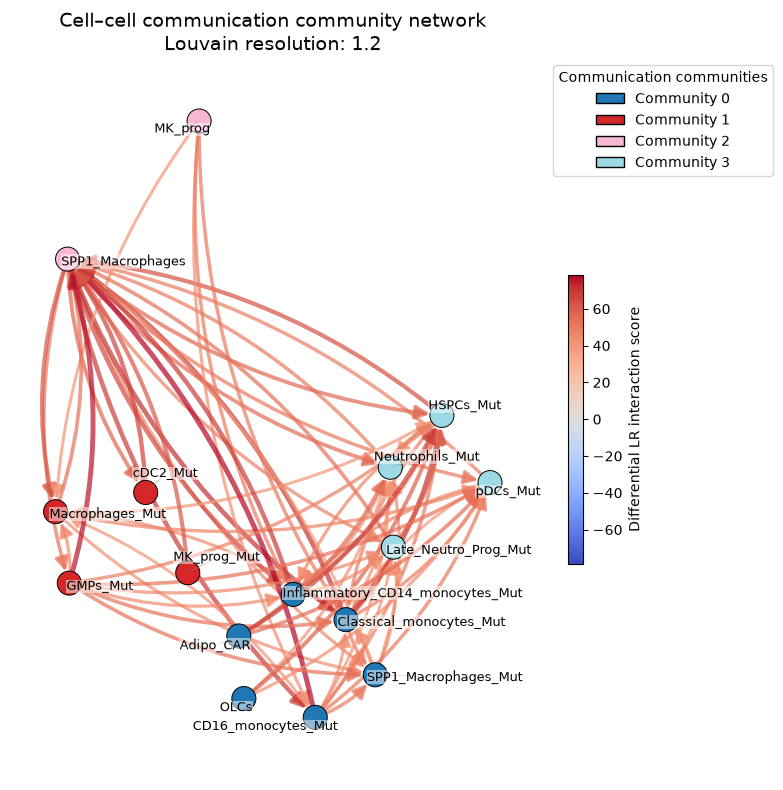

In [7]:
f=m04.cci_community_layout(
    #CCI_table,
    CCI_table_sub,
    method="louvain",
    res=1.2,
    compression=0.25,
    figsize=[8, 8]
)

f.savefig('../figures/revision/F7/F7E.pdf')

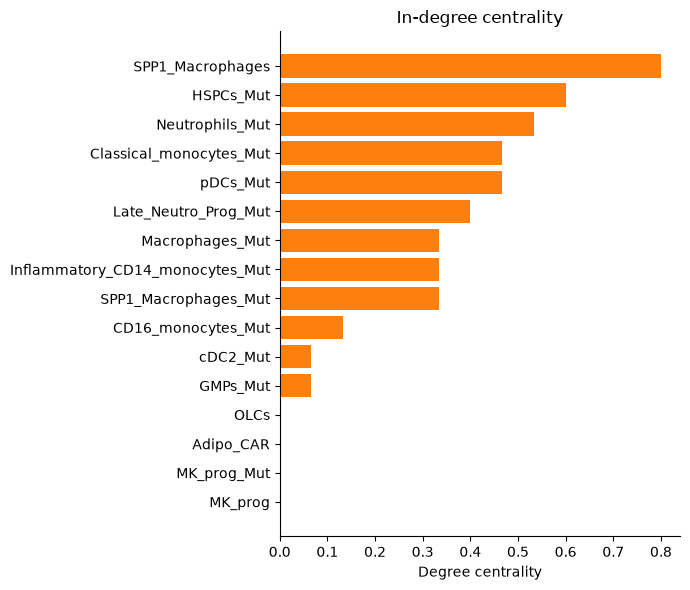

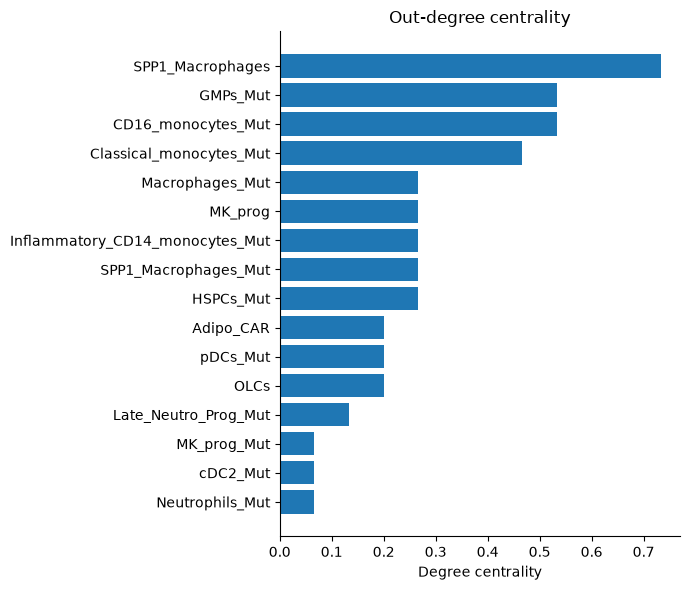

In [8]:
plt.rcParams['axes.facecolor'] = "None"
fig, deg = m04.plot_degree_centrality(CCI_table_sub)
plt.show()

In [9]:
fig[0].savefig('../figures/revision/FS7/FS7E.pdf')
fig[1].savefig('../figures/revision/FS7/FS7F.pdf')

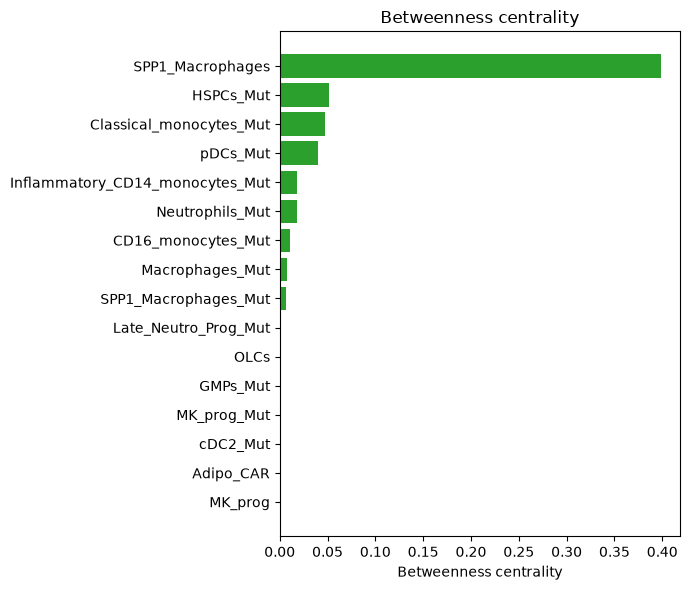

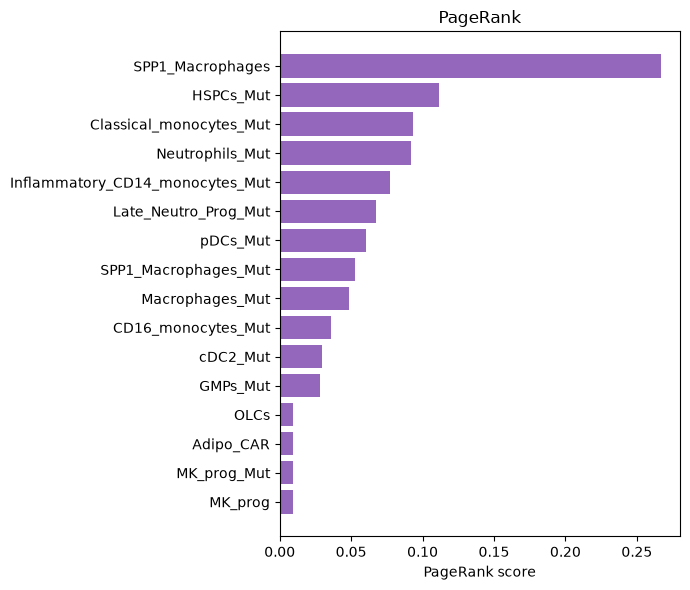

In [10]:
fig_bet, betweenness = m04.plot_betweenness_centrality(CCI_table_sub)
fig_pr, pagerank = m04.plot_pagerank(CCI_table_sub)
fig_bet.show()
fig_pr.show()

In [11]:
fig_bet.savefig('../figures/revision/FS7/FS7D.pdf')
fig_pr.savefig('../figures/revision/FS7/FS7G.pdf')

In [12]:
## Cell types selection

In [13]:
mut_nw=['pDCs_Mut',
 'HSPCs_Mut',
 'SPP1_Macrophages_Mut',
 'CD16_monocytes_Mut',
 'Macrophages_Mut',
 'Classical_monocytes_Mut',
 'GMPs_Mut',
 'Inflammatory_CD14_monocytes_Mut',
 'cDC2_Mut',
 'Neutrophils_Mut',
 'Late_Neutro_Prog_Mut',
 'MK_prog_Mut',
 'Adipo_CAR',
 'OLCs',
 'SPP1_Macrophages',
 'MK_prog']

In [14]:
## MF data from immunity paper
adata = sc.read_h5ad("../data/MF/MF_pre_treatment_Amplicon_object.h5ad") ## Jak2 object
adata.obsm['X_umap']=adata.obsm['X_harmony_umap']
adata

AnnData object with n_obs × n_vars = 58678 × 30096
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'pANN', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'G1.Score', 'CC.Difference', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'subcluster.mapping', 'subcluster', 'sample', 'annotation_05', 'timepoint', 'early_late', 'treatment', 'Cellnames', 'subcluster_mut'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_bcellcycle_pca', 'X_cellcycled_pca', 'X_default_umap', 'X_harmony', 'X_harmony_umap', 'X_inte_pca', 'X_inte_umap', 'X_raw_pca', 'X_regressout_pca', 'X_umap'

In [15]:
## add obs
adata.obs['CCcomm_tested']=list(adata.obs['subcluster_mut'].copy())

In [16]:
adata.obs['CCcomm_tested'][adata.obs['CCcomm_tested'].isin(mut_nw)==False]='Not_tested'
adata.obs['CCcomm_tested']=adata.obs['CCcomm_tested'].astype('category')

/tmp/ipykernel_3279962/2974519371.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs['CCcomm_tested'][adata.obs['CCcomm_tested'].isin(mut_nw)==False]='Not_tested'
/tmp/ipykernel_3279962/2974519371.py:1: SettingWithCopyWarning: 
A 

In [17]:
## Sort categories
no_priority_cells = ['Not_tested']
all_cats = list(adata.obs['CCcomm_tested'].cat.categories)
reorder_cats = no_priority_cells+[c for c in all_cats if c not in no_priority_cells]
adata.obs['CCcomm_tested'] = adata.obs['CCcomm_tested'].cat.reorder_categories(reorder_cats)
## Sort anndata
adata_ordered = adata[adata.obs['CCcomm_tested'].argsort()].copy()

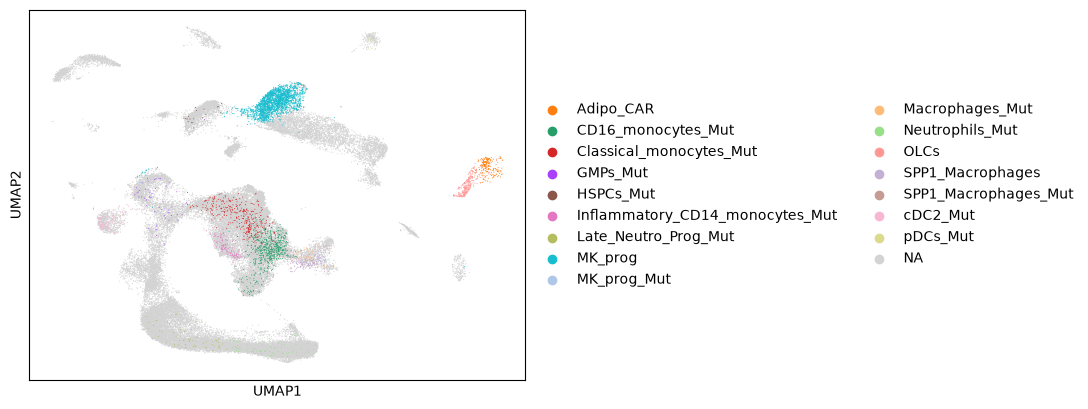

In [18]:
## UMAP
sc.pl.umap(adata_ordered, color='CCcomm_tested', title='', groups=mut)

In [19]:
adata_ordered_sub=adata_ordered[adata_ordered.obs['CCcomm_tested']!='Not_tested'].copy()

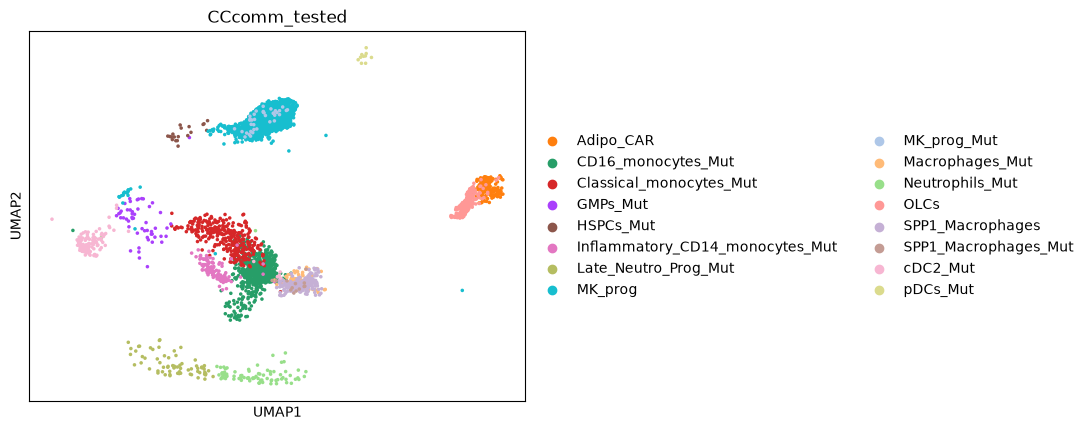

In [20]:
sc.pl.umap(adata_ordered_sub, color='CCcomm_tested')

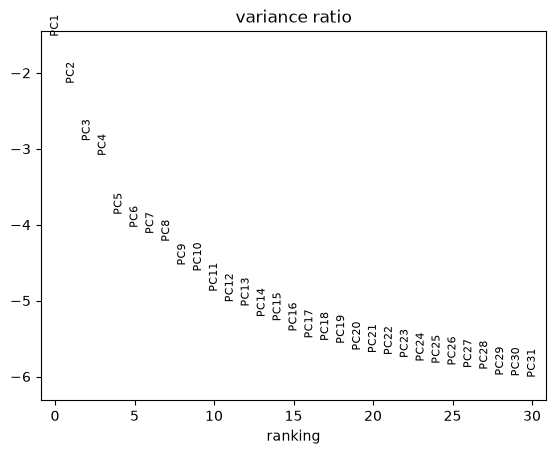

In [21]:
# Identify new HVGs specific to this subset
sc.pp.highly_variable_genes(
    adata_ordered_sub, 
    n_top_genes=2000, 
    flavor='seurat', 
    subset=False # Set to True if you want to discard non-HVGs immediately
)
# Recalculate PCA (uses highly variable genes by default)
sc.tl.pca(adata_ordered_sub, n_comps=50)
# Optional: Plot the PCA variance ratio to check dimensionality
sc.pl.pca_variance_ratio(adata_ordered_sub, log=True)

In [22]:
# Compute neighbors using the PCA coordinates
sc.pp.neighbors(adata_ordered_sub, n_pcs=30)
# Compute and embed the UMAP
sc.tl.umap(adata_ordered_sub)

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


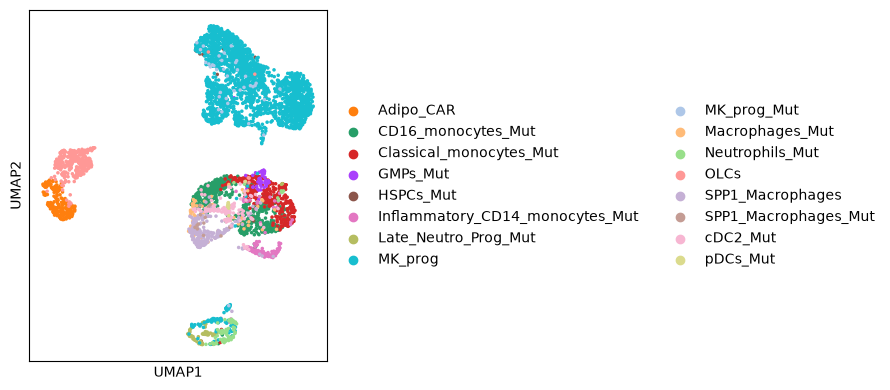

In [23]:
#sc.pl.umap(adata_ordered_sub, color='CCcomm_tested')
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
sc.pl.umap(adata_ordered_sub, color='CCcomm_tested', title='', ax=ax, show=False)
plt.tight_layout()
for collection in ax.collections:
    collection.set_rasterized(True)
plt.savefig('../figures/revision/F7/F7D.pdf', dpi=300)
plt.show()

In [24]:
adata_ordered_sub

AnnData object with n_obs × n_vars = 4595 × 30096
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'pANN', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'G1.Score', 'CC.Difference', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'subcluster.mapping', 'subcluster', 'sample', 'annotation_05', 'timepoint', 'early_late', 'treatment', 'Cellnames', 'subcluster_mut', 'CCcomm_tested'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CCcomm_tested_colors', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_bcellcycle_pca', 'X_cellcycled_pca', 'X_default_umap', 'X_harmony', 'X_harmony_umap', 'X_inte_pca', 'X_inte_umap', 'X_raw_pca', 'X_regressout_pca'

In [25]:
adata_ordered_sub.obs.CCcomm_tested.value_counts()

CCcomm_tested
MK_prog                            2313
CD16_monocytes_Mut                  622
Classical_monocytes_Mut             361
OLCs                                297
Adipo_CAR                           215
SPP1_Macrophages                    204
cDC2_Mut                            123
Inflammatory_CD14_monocytes_Mut     121
Neutrophils_Mut                      79
Late_Neutro_Prog_Mut                 67
Macrophages_Mut                      61
GMPs_Mut                             53
MK_prog_Mut                          37
HSPCs_Mut                            19
SPP1_Macrophages_Mut                 13
pDCs_Mut                             10
Name: count, dtype: int64

In [26]:
adata_ordered_sub.obs['sample'].value_counts()

sample
MF6_D0        1195
MF10_D0        873
MF2_D0_rep     751
MF11_D0        551
MF7_D0_rep     499
MF8_D0         389
MF1_D0         124
MF2_D0          92
MF3_D0          56
MF7_D0          49
MF4_D0          16
Name: count, dtype: int64

In [27]:
list(adata_ordered_sub.obs['sample'].unique().sort_values())

['MF1_D0',
 'MF2_D0',
 'MF2_D0_rep',
 'MF3_D0',
 'MF4_D0',
 'MF6_D0',
 'MF7_D0',
 'MF7_D0_rep',
 'MF8_D0',
 'MF10_D0',
 'MF11_D0']